In [1]:
from math import e

#Defining MDP
all_states = []
for x in range(21):
    for y in range(21):
        all_states.append((x, y))

rental_mdp = {st:{} for st in all_states}
discount_factor = 0.9
move_actions = [mv for mv in range(-5, 6)]

pois_cache = {}

lambda_rentA = 3
lambda_rentB = 4
lambda_retA = 3
lambda_retB = 2

factorials = [1]*21
for k in range(1, 21):
    factorials[k] = factorials[k-1]*k

max_cap = 10
for lam in set([lambda_rentA, lambda_rentB, lambda_retA, lambda_retB]):
    arr = [0.0]*(max_cap+1)
    exp_term = e**(-lam)
    for n in range(max_cap):
        arr[n] = ((lam**n)/factorials[n]) * exp_term
    arr[max_cap] = 1 - sum(arr[:max_cap])
    pois_cache[lam] = arr

def check_converge(oldV, newV, tol):
    return max(abs(newV[s] - oldV[s]) for s in oldV) > tol

In [2]:
prob_table = pois_cache

for st in all_states:
    trans_dict = {}
    for act in move_actions:
        if act > st[0] or -act > st[1]:
            trans_dict[act] = [(0, st, 0.0)]
            continue
        temp_store = {}
        curr = [st[0] - act, st[1] + act]
        if curr[0] < 0 or curr[1] < 0:
            continue        
        curr[0] = min(curr[0], 20)
        curr[1] = min(curr[1], 20)
        
        for rentA in range(max_cap+1):
            for rentB in range(max_cap+1):
                for retA in range(max_cap+1):
                    for retB in range(max_cap+1):
                        realA = min(rentA, curr[0])
                        realB = min(rentB, curr[1])                        
                        nxt = (
                            int(max(0, min(curr[0] - realA + retA, 20))),
                            int(max(0, min(curr[1] - realB + retB, 20)))
                        )                        
                        probability = (prob_table[lambda_rentA][rentA] *
                                       prob_table[lambda_rentB][rentB] *
                                       prob_table[lambda_retA][retA] *
                                       prob_table[lambda_retB][retB])                        
                        reward_val = -2*abs(act) + realA*10 + realB*10                        
                        if nxt not in temp_store:
                            temp_store[nxt] = [0.0, 0.0]                        
                        temp_store[nxt][0] += probability
                        temp_store[nxt][1] += probability * reward_val
        
        temp_list = []
        for st2 in all_states:
            if st2 in temp_store:
                if temp_store[st2][0] > 0:
                    temp_store[st2][1] /= temp_store[st2][0]
                    temp_list.append((temp_store[st2][0], st2, temp_store[st2][1]))
        
        trans_dict[act] = temp_list
    
    rental_mdp[st] = trans_dict

5


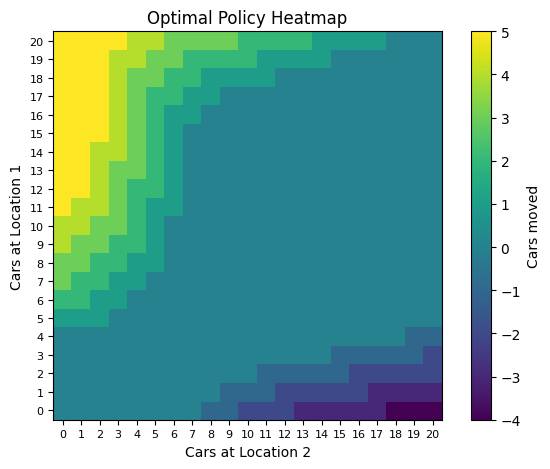

In [3]:

import numpy as np
import matplotlib.pyplot as plt

V_func = {}
V_new = {}
policy_old = {}
policy_new = {}

for st in all_states:
    V_func[st] = 10.0
    V_new[st] = 0.0
    policy_old[st] = 5
    policy_new[st] = 0

tol_val = 1e-4
iteration = 0

while policy_new != policy_old:
    iteration += 1
    
    for st in all_states:
        V_func[st] = 10.0
        V_new[st] = 0.0
    
    policy_old = policy_new.copy()
    
    # Policy Evaluation
    while check_converge(V_new, V_func, tol_val):
        V_func = V_new.copy()
        for st in all_states:
            total = 0
            trans = rental_mdp[st][policy_new[st]]
            for item in trans:
                total += item[0] * (item[2] + discount_factor * V_func[item[1]])
            V_new[st] = total

    # Policy Improvement
    for st in all_states:
        best_action = 0
        best_val = -float('inf')
        
        for act in move_actions:
            expected = 0
            trans = rental_mdp[st][act]
            for item in trans:
                expected += item[0] * (item[2] + discount_factor * V_new[item[1]])
            
            if expected > best_val:
                best_action = act
                best_val = expected
        
        policy_new[st] = best_action


print(iteration)

policy_matrix = np.zeros((21,21))
for (locA, locB), act in policy_new.items():
    policy_matrix[locA, locB] = act

img = plt.imshow(policy_matrix, origin="lower", cmap="viridis", interpolation="nearest")
plt.colorbar(img, label="Cars moved")
plt.xlabel("Cars at Location 2")
plt.ylabel("Cars at Location 1")
plt.title("Optimal Policy Heatmap")

plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 21, 1))
plt.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

In [4]:
for st in all_states:
    V_func[st] = 10.0
    V_new[st] = 0.0

# Final Policy Evaluation
while check_converge(V_new, V_func, tol_val):
    V_func = V_new.copy()
    for st in all_states:
        total = 0
        trans = rental_mdp[st][policy_new[st]]
        for item in trans:
            total += item[0] * (item[2] + discount_factor * V_func[item[1]])
        V_new[st] = total

print(V_new)

{(0, 0): 421.3938273034233, (0, 1): 431.3660504153896, (0, 2): 441.2217510013677, (0, 3): 450.82710200029277, (0, 4): 460.0599702176655, (0, 5): 468.85217605335913, (0, 6): 477.19063013234864, (0, 7): 485.0944689047992, (0, 8): 492.9577719172782, (0, 9): 500.4535769063652, (0, 10): 507.86568169604993, (0, 11): 514.9711769873595, (0, 12): 521.7279572565349, (0, 13): 528.3282624811038, (0, 14): 534.7168394810857, (0, 15): 540.8033817783012, (0, 16): 546.606154687021, (0, 17): 552.1414892011142, (0, 18): 557.565637888492, (0, 19): 562.7682967078297, (0, 20): 567.7176151079858, (1, 0): 431.2675834570991, (1, 1): 441.23974036375995, (1, 2): 451.0951124289143, (1, 3): 460.69962085765934, (1, 4): 469.930985289198, (1, 5): 478.7210594118841, (1, 6): 487.0568994542543, (1, 7): 494.95777191727814, (1, 8): 502.45357690636536, (1, 9): 509.8656816960501, (1, 10): 516.9711769873595, (1, 11): 523.727957256534, (1, 12): 530.3282624811033, (1, 13): 536.716839481086, (1, 14): 542.8033817783012, (1, 15):